**Week 9 Instructor-led Lab**

# Descriptive Statistics

Author: Magdalena Gerharter  
Course: BGEN 632 Grad. Intro. to Python  
Term: Spring 2025

## Import Modules

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression
from datetime import date

## Set working directory

In [16]:
os.chdir("/Users/magdalenagerharter/Documents/GitHub/week7labs/data")
os.getcwd()  #confirm change

'/Users/magdalenagerharter/Documents/GitHub/week7labs/data'

In [17]:
hospital_data = pd.read_csv("CaliforniaHospitalData.csv")
personnel_data = pd.read_csv("CaliforniaHospitalData_Personnel.txt", delimiter = "\t")

## Prep Data

In [19]:
merged = pd.merge(hospital_data, personnel_data, on='HospitalID', how='inner')

In [20]:
merged_drop = merged.drop(columns=['Work_ID', 'PositionID', 'Website'])
merged_drop

,HospitalID,Name,Zip,TypeControl,Teaching,DonorType,NoFTE,NetPatRev,InOperExp,OutOperExp,...,AvlBeds,LastName,FirstName,Gender,PositionTitle,Compensation,MaxTerm,StartDate,Phone,Email
0,45740,Mammoth Hospital,93546-0660,District,Small/Rural,Charity,327.0,1.355202e+05,2.052343e+07,3.491622e+07,...,15,Web,David,M,Safety Inspection Member,23987,2,1/1/2012,785-532-2452,david.web@comenitymed.com
1,12145,Victor Valley Community Hospital,92392,Non Profit,Small/Rural,Charity,345.0,1.361567e+05,3.344754e+07,2.034860e+07,...,99,Rodriguez,Jose,M,Regional Representative,46978,4,1/1/2009,405-744-2238,jose.rodriguez@edihealth.com
2,25667,Pioneers Memorial Hospital,92227,District,Small/Rural,Charity,601.2,1.970943e+05,3.725418e+07,3.783245e+07,...,107,Adamson,David,M,Regional Representative,46978,4,1/1/2012,785-532-7573,david.adamson@txbiomed.net
3,46996,Ridgecrest Regional Hospital,93555,Non Profit,Small/Rural,Charity,400.0,1.391704e+05,2.338557e+07,2.466136e+07,...,55,Roberts,Melissa,F,Safety Inspection Member,23987,2,1/1/2009,785-532-9779,melissa.roberts@txbiomed.net
4,37393,Barstow Community Hospital,92311,Investor,Small/Rural,Charity,262.0,1.167978e+05,1.368450e+07,1.515999e+07,...,42,Iwata,Akira,M,Regional Representative,46978,4,1/1/2011,801-611-9161,akira.iwata@hsu.edu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,32930,Scripps Mercy Hospital,92103,Non Profit,Teaching,Alumni,2814.0,1.321032e+06,3.791029e+08,1.064302e+08,...,530,Manin,Emily,F,Regional Representative,46978,4,1/1/2011,801-223-6845,emily.manin@ihc.com
57,31032,Long Beach Memorial & Miller Children's Hospital,90806,Non Profit,Teaching,Alumni,5218.0,1.187022e+06,2.912481e+08,1.093286e+08,...,462,Dong,HongWei,F,Safety Inspection Member,23987,2,1/1/2012,479-354-4864,hongwei.dong@brokenhealth.com
58,22460,Stanford Hospital & Clinics,94305,Non Profit,Teaching,Alumni,6392.0,4.333934e+06,9.289621e+08,6.621559e+08,...,445,Smith,Mary,F,Safety Inspection Member,23987,2,1/1/2012,469-767-5485,mary.smith@ihc.com
59,33192,California Pacific Medical Center - Pacific Ca...,94115,Non Profit,Teaching,Alumni,1565.1,2.736281e+06,6.337903e+08,2.960207e+08,...,730,Fourier,Craig,M,Regional Representative,46978,4,1/1/2011,503-235-4877,craig.fourier@comenitymed.com


In [21]:
new_employee = pd.DataFrame([
    {
        'HospitalID': merged_drop.iloc[0]['HospitalID'],
        'LastName': 'Gerharter',
        'FirstName': 'Magdalena',
        'Gender': 'F',
        'PositionTitle': 'State Board Representative',
        'Compensation': 89473,
        'MaxTerm': 3,
        'StartDate': date.today(),
        'Name': 'Sloan Grey Memorial',
        'Zip': 59801,
        'TypeControl':'Non-Profit',
        'Teaching': 'Yes',
        'DonorType': 'Corporate',
        'NoFTE': 300,
        'NetPatRev': 1500000,
        'InOperExp': 800000,
        'OutOperExp': 300000,
        'OperRev': 1800000,
        'OperInc': 70000,
        'AvlBeds': 40
    }])


In [22]:
new_merge = pd.concat([merged_drop, new_employee])

In [23]:
new_merge['StartDate'] = pd.to_datetime(new_merge['StartDate'])

In [24]:
new_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 0
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   HospitalID     62 non-null     int64         
 1   Name           62 non-null     object        
 2   Zip            62 non-null     object        
 3   TypeControl    62 non-null     object        
 4   Teaching       62 non-null     object        
 5   DonorType      62 non-null     object        
 6   NoFTE          62 non-null     float64       
 7   NetPatRev      62 non-null     float64       
 8   InOperExp      62 non-null     float64       
 9   OutOperExp     62 non-null     float64       
 10  OperRev        62 non-null     int64         
 11  OperInc        62 non-null     int64         
 12  AvlBeds        62 non-null     int64         
 13  LastName       62 non-null     object        
 14  FirstName      62 non-null     object        
 15  Gender         62 non-null     

In [25]:
categorical_cols =['TypeControl', 'Teaching', 'DonorType', 'Gender']
for col in categorical_cols:
    new_merge[col] = new_merge[col].astype('category')

In [26]:
new_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 0
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   HospitalID     62 non-null     int64         
 1   Name           62 non-null     object        
 2   Zip            62 non-null     object        
 3   TypeControl    62 non-null     category      
 4   Teaching       62 non-null     category      
 5   DonorType      62 non-null     category      
 6   NoFTE          62 non-null     float64       
 7   NetPatRev      62 non-null     float64       
 8   InOperExp      62 non-null     float64       
 9   OutOperExp     62 non-null     float64       
 10  OperRev        62 non-null     int64         
 11  OperInc        62 non-null     int64         
 12  AvlBeds        62 non-null     int64         
 13  LastName       62 non-null     object        
 14  FirstName      62 non-null     object        
 15  Gender         62 non-null     

## Descriptive Statistics

### Numeric Summary

In [29]:
new_merge.describe(include=['number'])

,HospitalID,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds,Compensation,MaxTerm
count,62.000000,62.000000,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,62.000000,62.000000,62.000000
mean,32052.838710,1333.324516,6.829774e+05,1.636017e+08,8.870876e+07,2.521689e+08,-1.517144e+05,192.032258,92721.467742,4.225806
std,11065.265699,2013.039938,1.093577e+06,2.812463e+08,1.366371e+08,4.227244e+08,7.095572e+07,220.880649,83849.213062,2.099331
min,10767.000000,55.000000,1.417224e+04,8.000000e+05,3.000000e+05,1.800000e+06,-3.211633e+08,12.000000,23987.000000,2.000000
25%,21335.000000,216.375000,7.284830e+04,1.363109e+07,1.425996e+07,2.403641e+07,-1.028922e+06,42.000000,46978.000000,3.000000
50%,33267.000000,368.660000,1.728132e+05,3.124469e+07,3.259692e+07,6.153388e+07,1.464124e+06,99.000000,46978.000000,4.000000
75%,39108.000000,1137.000000,6.780524e+05,1.639284e+08,8.867309e+07,1.982414e+08,6.146421e+06,228.250000,89473.000000,4.000000
max,46996.000000,8000.000000,4.662582e+06,1.285631e+09,6.621559e+08,1.912179e+09,1.648724e+08,909.000000,248904.000000,8.000000


In [30]:
new_merge.describe(include=['number']).agg(['mean','50%','min','max'])

,HospitalID,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds,Compensation,MaxTerm
mean,24331.638051,1648.174932,9.221355e+05,2.425104e+08,1.279165e+08,3.590856e+08,-9.863154e+06,220.645363,79119.0851,11.165642
50%,33267.000000,368.660000,1.728132e+05,3.124469e+07,3.259692e+07,6.153388e+07,1.464124e+06,99.000000,46978.0000,4.000000
min,62.000000,55.000000,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,-3.211633e+08,12.000000,62.0000,2.000000
max,46996.000000,8000.000000,4.662582e+06,1.285631e+09,6.621559e+08,1.912179e+09,1.648724e+08,909.000000,248904.0000,62.000000


### Text Summary

In [32]:
new_merge.describe(include=['object'])

,Name,Zip,LastName,FirstName,PositionTitle,Phone,Email
count,62,62,62,62,62,61,61
unique,62,62,24,20,4,24,24
top,Mammoth Hospital,93546-0660,Smith,David,Regional Representative,785-532-2452,david.web@comenitymed.com
freq,1,1,4,6,24,3,3


### Categorical summary

In [34]:
new_merge.describe(include=['category'])

,TypeControl,Teaching,DonorType,Gender
count,62,62,62,62
unique,5,3,3,2
top,Non Profit,Small/Rural,Charity,F
freq,37,44,44,33


### Histograms

<Axes: ylabel='Frequency'>

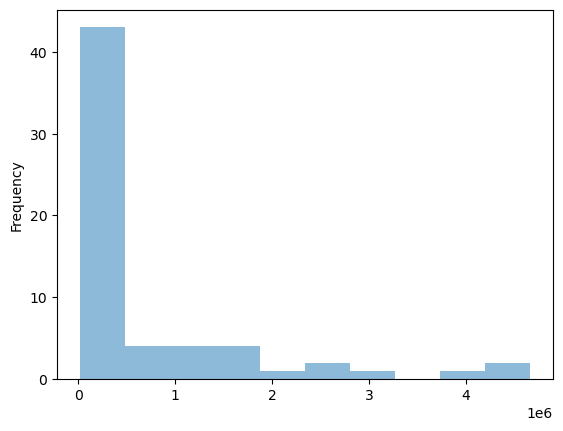

In [36]:
new_merge['NetPatRev'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

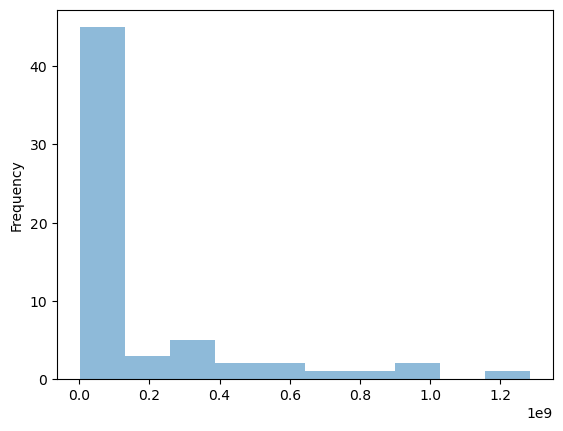

In [37]:
new_merge['InOperExp'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

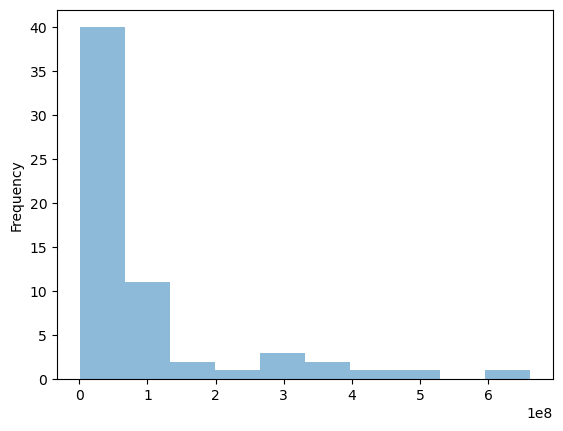

In [38]:
new_merge['OutOperExp'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

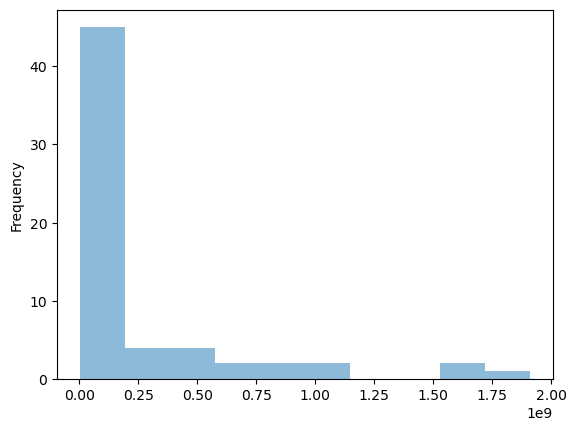

In [39]:
new_merge['OperRev'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

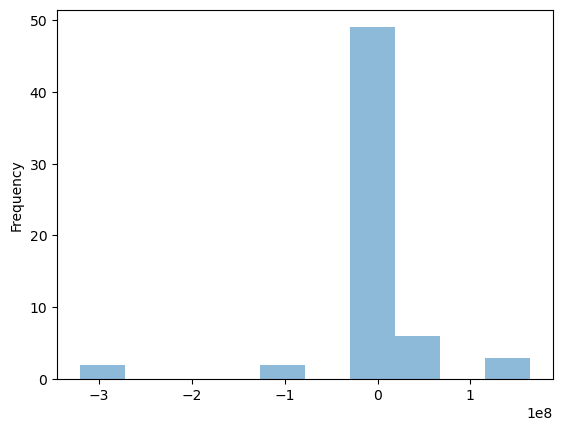

In [40]:
new_merge['OperInc'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

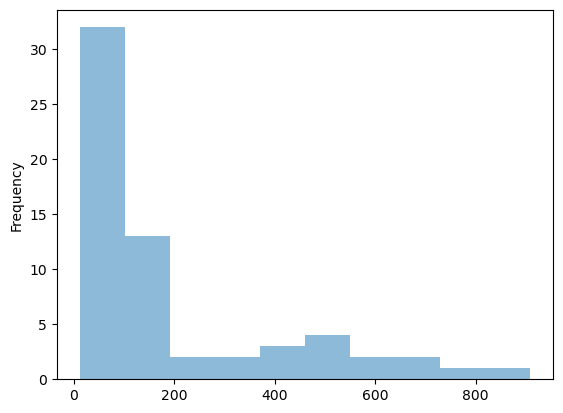

In [41]:
new_merge['AvlBeds'].plot.hist(alpha=0.5)

### Scatterplots

<Axes: xlabel='NoFTE', ylabel='NetPatRev'>

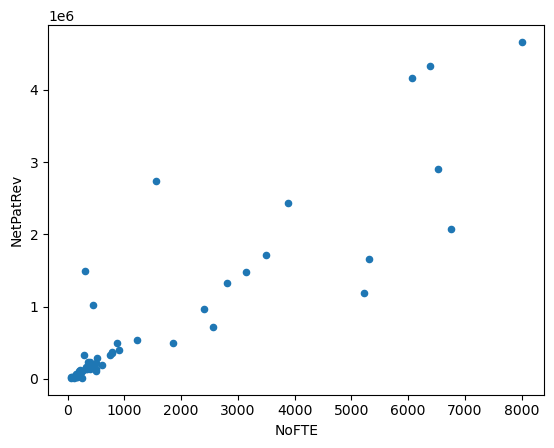

In [43]:
new_merge.plot.scatter(x='NoFTE', y='NetPatRev')

<Axes: xlabel='InOperExp', ylabel='NetPatRev'>

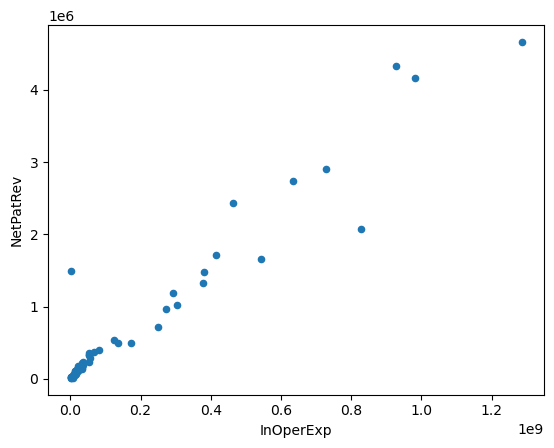

In [44]:
new_merge.plot.scatter(x='InOperExp', y='NetPatRev')

<Axes: xlabel='OutOperExp', ylabel='NetPatRev'>

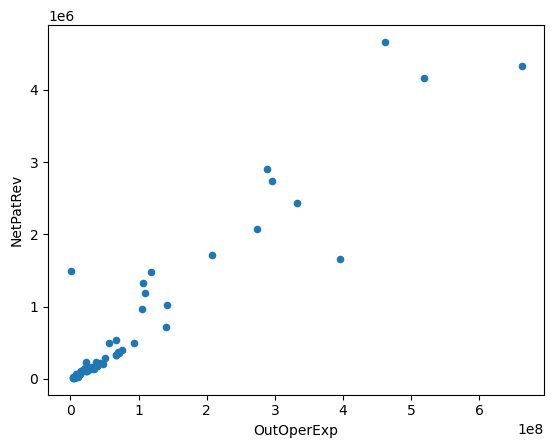

In [45]:
new_merge.plot.scatter(x='OutOperExp', y='NetPatRev')

<Axes: xlabel='OperRev', ylabel='NetPatRev'>

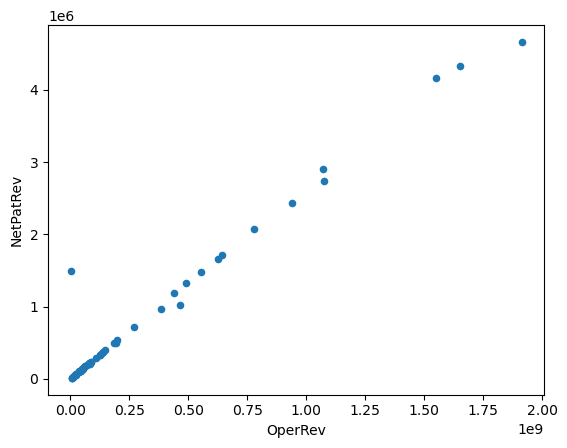

In [46]:
new_merge.plot.scatter(x='OperRev', y='NetPatRev')

<Axes: xlabel='OperInc', ylabel='NetPatRev'>

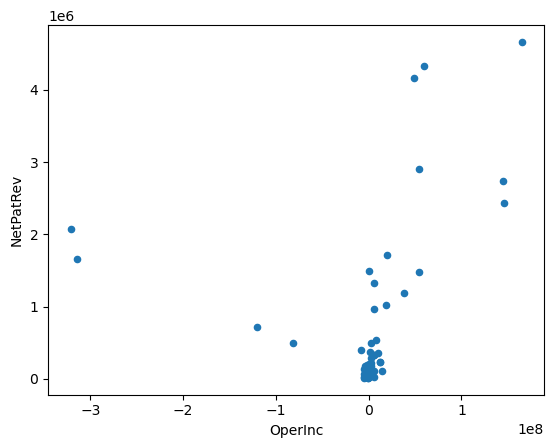

In [47]:
new_merge.plot.scatter(x='OperInc', y='NetPatRev')

<Axes: xlabel='AvlBeds', ylabel='NetPatRev'>

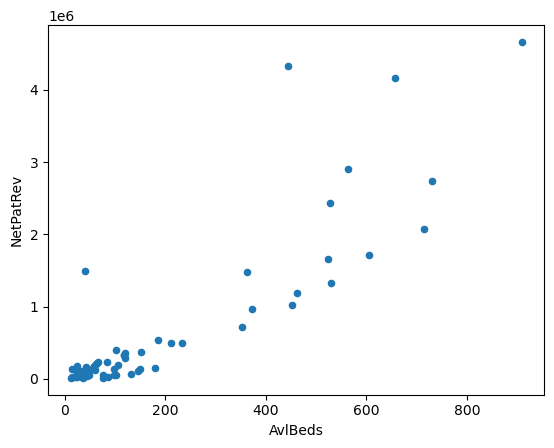

In [48]:
new_merge.plot.scatter(x='AvlBeds', y='NetPatRev')

NoFTE vs. NetPatRev
- Moderate to strong positive linear relationship

InOperExp vs. NetPatRev  
- Strong positive linear relationship
  
OutOperExp vs. NetPatRev  
- Moderate to strong positive linear relationship

OperRev vs. NetPatRev  
- Strong positive linear relationship

OperInc vs. NetPatRev  
- Weak to moderate positive linear trend

AvlBeds vs. NetPatRev  
- Weak to moderate positive linear trend

### Boxplot

<Axes: >

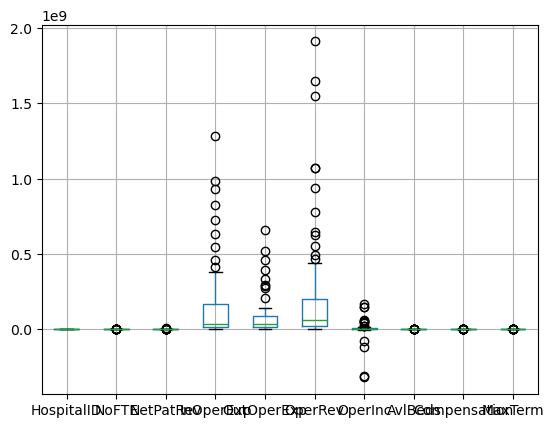

In [51]:
new_merge.boxplot()

<Axes: >

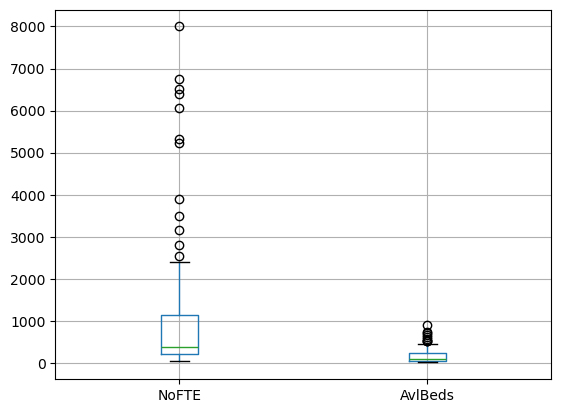

In [52]:
new_merge.loc[:,['NoFTE','AvlBeds']].boxplot() # Group 1

<Axes: >

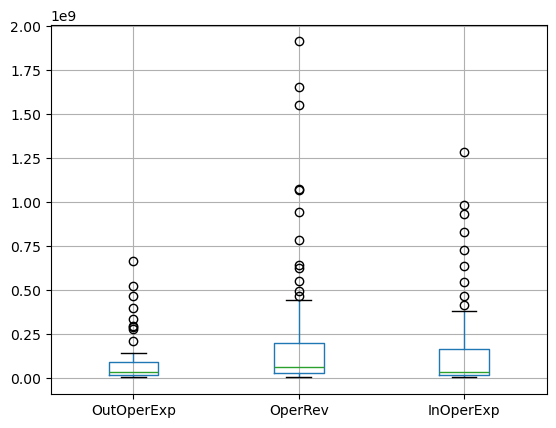

In [53]:
new_merge.loc[:,['OutOperExp','OperRev', 'InOperExp']].boxplot() # Group 2

<Axes: >

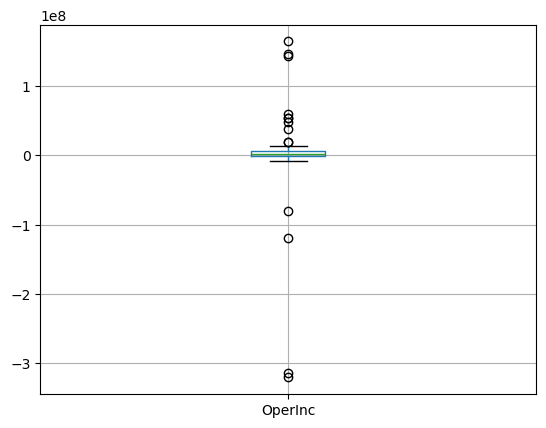

In [54]:
new_merge.loc[:,['OperInc']].boxplot() # Group 3

<Axes: >

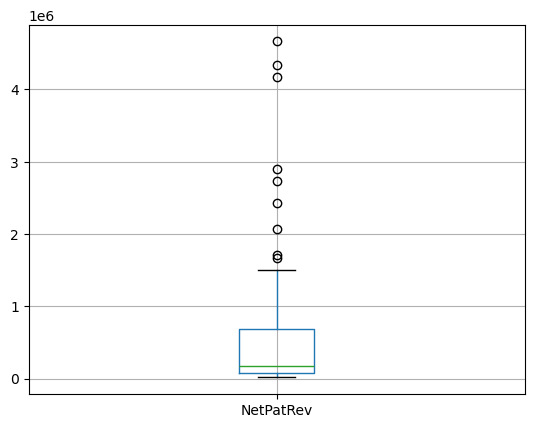

In [55]:
new_merge.loc[:,['NetPatRev']].boxplot() # Group 4

Most variables show the presence of outliers. Financial variables like NetPatRev, OperRev, InOperExp, and OutOperExp have the most extreme outliers. These likely reflect larger hospitals with higher revenues and expenses. NoFTE, OperInc, and AvlBeds also show outliers, but distributions are tighter. The data suggests variation in hospital size and operations.

### QQ Plot

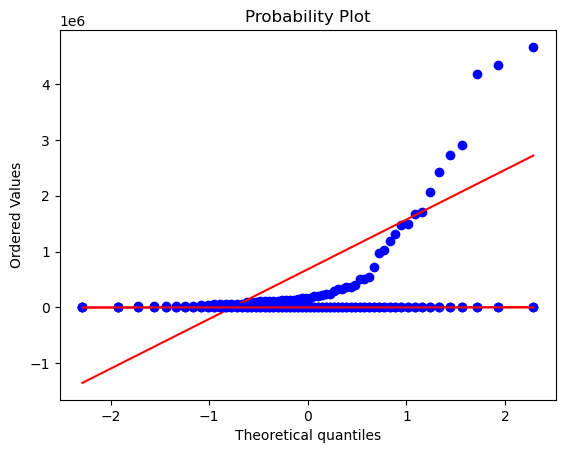

In [58]:
for var in ['NoFTE','NetPatRev','AvlBeds']:
    sts.probplot(new_merge[var], dist="norm", plot=plt)

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([  55.  ,   67.  ,   75.  ,  100.  ,  121.  ,  150.  ,  158.  ,
   

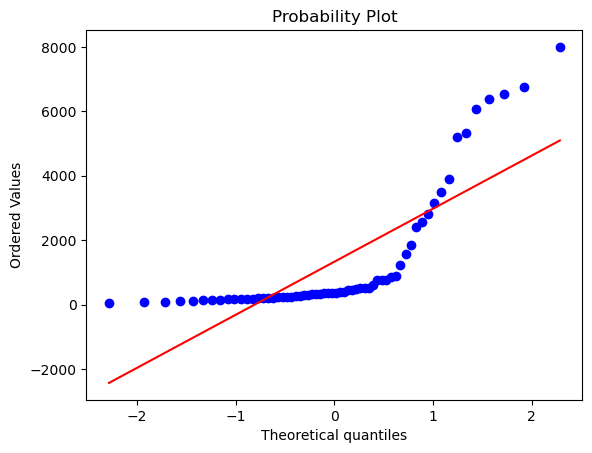

In [59]:
sts.probplot(new_merge['NoFTE'], dist="norm", plot=plt)

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([  14172.24044,   14313.04918,   17566.92896,   26260.51366,
      

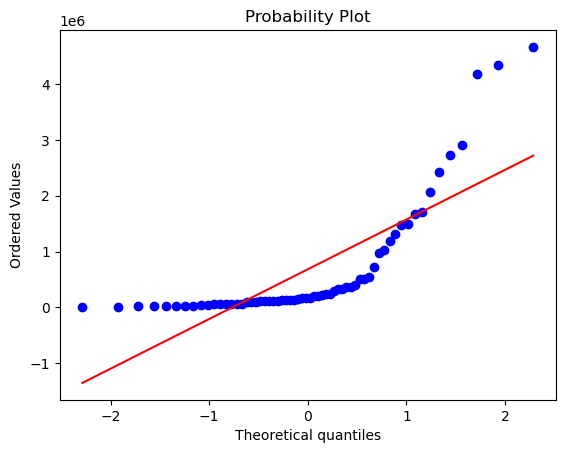

In [60]:
sts.probplot(new_merge['NetPatRev'], dist="norm", plot=plt)

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([ 12,  15,  15,  20,  25,  25,  25,  25,  26,  28,  35,  35,  37,
 

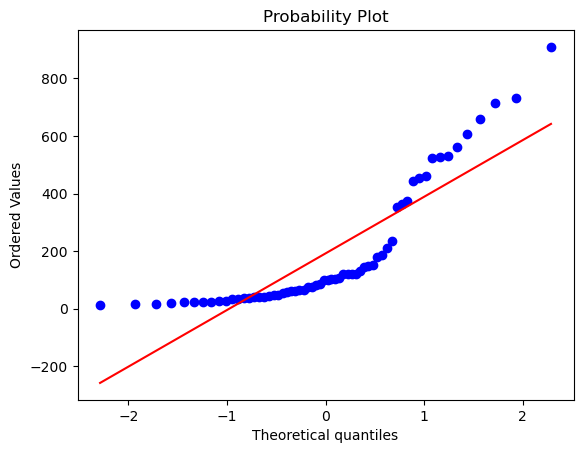

In [61]:
sts.probplot(new_merge['AvlBeds'], dist="norm", plot=plt)

- NoFTE: Points move away from the line at both ends, suggesting a right-skewed distribution — not normally distributed.  
- NetPatRev: Big deviation from the line, especially at the higher values — highly skewed, not normal.  
- AvlBeds: close to the line in the middle, but the tails show some deviation  — moderate skew, somewhat normal but not perfect.

### Shapiro-Wilk test

In [64]:
sts.shapiro(new_merge['NoFTE'])

ShapiroResult(statistic=0.6401861429103788, pvalue=4.646277094046949e-11)

In [65]:
sts.shapiro(new_merge['NetPatRev'])

ShapiroResult(statistic=0.636772328031316, pvalue=4.058223025525961e-11)

In [66]:
sts.shapiro(new_merge['AvlBeds'])

ShapiroResult(statistic=0.7571336136621767, pvalue=9.054100206085826e-09)

Shapiro-Wilk test:  
- p-value < 0.05 => not normally distributed
- p-value > 0.05 => might be normally distributed

1. NoFTE:  
    very low p-value -> not normally distributed  
    
2. NetPatRev:  
    very low p-value -> not normall distributed  

3. AvlBeds:  
    very low p-value -> not normall distributed


The results from the Shapiro-Wilk test confirm what I concluded form the QQ plots.